In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

from implicit.als import AlternatingLeastSquares
from catboost import CatBoostRanker, Pool

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — beeswarm plot будет пропущен. pip install shap чтобы включить.')

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports OK')

shap not installed — beeswarm plot будет пропущен. pip install shap чтобы включить.
Imports OK


In [2]:
SEED = 42
DATA_PATH = '../data/children_products/clildren_product_cleaned.csv'
MIN_INTERACTIONS = 3
SPLIT_QUANTILE = 0.7
K_VALUES = [5, 10, 20]
N_CANDIDATES = 100

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df = df.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df = df.dropna(subset=['Дата'])

if 'Цена' in df.columns:
    df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')

uc = df.groupby('Телефон_new').size()
ic = df.groupby('ID_SKU').size()
df = df[
    df['Телефон_new'].isin(uc[uc >= MIN_INTERACTIONS].index) &
    df['ID_SKU'].isin(ic[ic >= MIN_INTERACTIONS].index)
]
print(f'After filter: users={df["Телефон_new"].nunique():,}, '
      f'items={df["ID_SKU"].nunique():,}, rows={len(df):,}')

After filter: users=35,395, items=22,198, rows=314,493


In [3]:
interactions = (
    df.groupby(['Телефон_new', 'ID_SKU'])
      .agg(last_date=('Дата', 'max'),
           mean_date=('Дата', 'mean'),
           count=('Дата', 'count'))
      .reset_index()
)

user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_id'] = user_enc.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_enc.fit_transform(interactions['ID_SKU'])

# Применяем те же encoders к raw df — нужно для последующего feature engineering
df['user_id'] = user_enc.transform(df['Телефон_new'])
df['item_id'] = item_enc.transform(df['ID_SKU'])

n_users = interactions['user_id'].nunique()
n_items = interactions['item_id'].nunique()
print(f'Unique pairs: {len(interactions):,}, n_users={n_users:,}, n_items={n_items:,}')
# expected: 287,360 / 35,395 / 22,198

Unique pairs: 287,360, n_users=35,395, n_items=22,198


In [4]:
split_ts = interactions['last_date'].quantile(SPLIT_QUANTILE)
print(f'Split timestamp: {split_ts}')

train_df = interactions[interactions['last_date'] <  split_ts].copy()
test_df  = interactions[interactions['last_date'] >= split_ts].copy()

train_users = set(train_df['user_id'].unique())
test_warm = test_df[test_df['user_id'].isin(train_users)].copy()

# Raw transactions для training period — нужно для feature engineering
train_raw = df[df['Дата'] < split_ts].copy()

print(f'Train pairs: {len(train_df):,} / {train_df["user_id"].nunique():,} users')
print(f'Test warm:   {len(test_warm):,} / {test_warm["user_id"].nunique():,} users')
print(f'Train raw transactions: {len(train_raw):,}')
# expected: 201,147 / 28,017; 42,415 / 7,128

Split timestamp: 2017-04-12 17:37:00
Train pairs: 201,147 / 28,017 users
Test warm:   42,415 / 7,128 users
Train raw transactions: 225,586


In [5]:
ALS_BEST_FACTORS        = 98
ALS_BEST_REGULARIZATION = 9.523948773100468
ALS_BEST_ITERATIONS     = 40

ALS_USE_TIME_DECAY      = True
ALS_BEST_LAMBDA         = 0.001

print(f'ALS hyperparams: factors={ALS_BEST_FACTORS}, reg={ALS_BEST_REGULARIZATION}, '
      f'iter={ALS_BEST_ITERATIONS}, time_decay={ALS_USE_TIME_DECAY} (λ={ALS_BEST_LAMBDA})')

ALS hyperparams: factors=98, reg=9.523948773100468, iter=40, time_decay=True (λ=0.001)


In [6]:
if ALS_USE_TIME_DECAY:
    days = (split_ts - train_df['mean_date']).dt.total_seconds() / 86400
    weights = (train_df['count'].values * np.exp(-ALS_BEST_LAMBDA * days.values)).clip(1e-6)
    print(f'Time-decay weights: [{weights.min():.4f}, {weights.max():.4f}]')
else:
    weights = train_df['count'].values.astype(float)

train_matrix = csr_matrix(
    (weights, (train_df['user_id'].values, train_df['item_id'].values)),
    shape=(n_users, n_items)
)
print(f'Train matrix: {train_matrix.shape}, nnz={train_matrix.nnz:,}')

als_model = AlternatingLeastSquares(
    factors=ALS_BEST_FACTORS,
    regularization=ALS_BEST_REGULARIZATION,
    iterations=ALS_BEST_ITERATIONS,
    random_state=SEED,
    calculate_training_loss=False,
)
als_model.fit(train_matrix)
print('ALS обучен')

Time-decay weights: [0.9582, 28.7614]
Train matrix: (35395, 22198), nnz=201,147


  0%|          | 0/40 [00:00<?, ?it/s]

ALS обучен


In [7]:
def precision_at_k(rec, rel, k):
    rec_k = set(rec[:k]); rel = set(rel)
    return len(rec_k & rel) / len(rec_k) if rec_k else 0.0

def recall_at_k(rec, rel, k):
    rec_k = set(rec[:k]); rel = set(rel)
    return len(rec_k & rel) / len(rel) if rel else 0.0

def map_at_k(rec, rel, k):
    rel = set(rel)
    if not rel: return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(rec[:k]):
        if item in rel:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel), k)

def ndcg_at_k(rec, rel, k):
    rel = set(rel)
    if not rel: return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, it in enumerate(rec[:k]) if it in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

def aggregate_metrics(per_user, k_values):
    return {
        k: {m: float(np.mean(per_user[k][m])) for m in ['precision','recall','map','ndcg']}
        for k in k_values
    }

In [8]:
test_user_items = test_warm.groupby('user_id')['item_id'].apply(list).to_dict()
eval_users = sorted([u for u in test_user_items if u in train_users])
print(f'Eval users (warm): {len(eval_users):,}')

als_per_user = {k: {'precision':[],'recall':[],'map':[],'ndcg':[]} for k in K_VALUES}
for u in eval_users:
    item_ids, _ = als_model.recommend(
        u, train_matrix[u], N=max(K_VALUES), filter_already_liked_items=True
    )
    rec = list(item_ids)
    rel = test_user_items[u]
    for k in K_VALUES:
        als_per_user[k]['precision'].append(precision_at_k(rec, rel, k))
        als_per_user[k]['recall'].append(recall_at_k(rec, rel, k))
        als_per_user[k]['map'].append(map_at_k(rec, rel, k))
        als_per_user[k]['ndcg'].append(ndcg_at_k(rec, rel, k))

als_results = aggregate_metrics(als_per_user, K_VALUES)
print('=== ALS baseline ===')
for k in K_VALUES:
    r = als_results[k]
    print(f'  K={k}: P={r["precision"]:.4f}  R={r["recall"]:.4f}  '
          f'MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')

Eval users (warm): 7,128
=== ALS baseline ===
  K=5: P=0.0513  R=0.0613  MAP=0.0492  NDCG=0.0715
  K=10: P=0.0395  R=0.0833  MAP=0.0458  NDCG=0.0746
  K=20: P=0.0299  R=0.1107  MAP=0.0462  NDCG=0.0822


In [9]:
rows = []
for u in eval_users:
    item_ids, scores = als_model.recommend(
        u, train_matrix[u], N=N_CANDIDATES, filter_already_liked_items=True
    )
    rel = set(test_user_items[u])
    for rank, (it, sc) in enumerate(zip(item_ids, scores)):
        rows.append({
            'user_id': u,
            'item_id': int(it),
            'als_score': float(sc),
            'als_rank': rank + 1,
            'label': int(int(it) in rel),
        })
candidates_df = pd.DataFrame(rows)
print(f'Кандидатов: {len(candidates_df):,}; positive ratio: {candidates_df["label"].mean():.4f}')

Кандидатов: 712,800; positive ratio: 0.0125


In [10]:
user_features = train_raw.groupby('user_id').agg(
    user_n_purchases=('Дата', 'count'),
    user_n_unique_items=('item_id', 'nunique'),
    user_avg_price=('Цена', 'mean'),
    user_total_margin=('Маржа', 'sum'),
    user_avg_margin=('Маржа', 'mean'),
).reset_index()

user_geo = train_raw.groupby('user_id')['Гео'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_geo.columns = ['user_id', 'user_geo']

user_delivery = train_raw.groupby('user_id')['МетодДоставки_Групп'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_delivery.columns = ['user_id', 'user_delivery_method']

user_features = user_features.merge(user_geo, on='user_id').merge(user_delivery, on='user_id')
print(f'User features: {user_features.shape}')

User features: (28469, 8)


In [11]:
item_features = train_raw.groupby('item_id').agg(
    item_n_purchases=('Дата', 'count'),
    item_n_unique_buyers=('user_id', 'nunique'),
    item_avg_price=('Цена', 'mean'),
    item_avg_margin=('Маржа', 'mean'),
).reset_index()

item_category = train_raw.groupby('item_id')['Группа2'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
item_category.columns = ['item_id', 'item_category']

item_features = item_features.merge(item_category, on='item_id')
print(f'Item features: {item_features.shape}')

Item features: (20745, 6)


In [12]:
dataset = candidates_df.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(item_features, on='item_id', how='left')

# ALS латентные фичи
user_factors = np.asarray(als_model.user_factors)
item_factors = np.asarray(als_model.item_factors)

u_vecs = user_factors[dataset['user_id'].values]
i_vecs = item_factors[dataset['item_id'].values]
dataset['als_dot']       = (u_vecs * i_vecs).sum(axis=1)
dataset['als_user_norm'] = np.linalg.norm(u_vecs, axis=1)
dataset['als_item_norm'] = np.linalg.norm(i_vecs, axis=1)
dataset['als_cosine']    = dataset['als_dot'] / (
    dataset['als_user_norm'] * dataset['als_item_norm'] + 1e-10
)

# Заполняем пропуски
num_cols = [c for c in dataset.select_dtypes(include=[np.number]).columns
            if c not in {'user_id', 'item_id', 'label'}]
for c in num_cols:
    dataset[c] = dataset[c].fillna(dataset[c].median())
for c in ['user_geo', 'user_delivery_method', 'item_category']:
    dataset[c] = dataset[c].fillna('Неизвестно')

print(f'Dataset shape: {dataset.shape}')
print(f'Missing: {dataset.isnull().sum().sum()}')

Dataset shape: (712800, 21)
Missing: 0


In [13]:
FEATURE_COLS = [
    'als_score', 'als_rank', 'als_dot', 'als_cosine',
    'als_user_norm', 'als_item_norm',
    'user_n_purchases', 'user_n_unique_items', 'user_avg_price',
    'user_total_margin', 'user_avg_margin',
    'user_geo', 'user_delivery_method',
    'item_n_purchases', 'item_n_unique_buyers',
    'item_avg_price', 'item_avg_margin', 'item_category',
]
CAT_FEATURES = ['user_geo', 'user_delivery_method', 'item_category']

all_users_arr = np.array(eval_users)
rng = np.random.default_rng(SEED)
rng.shuffle(all_users_arr)
split_idx = int(len(all_users_arr) * 0.8)
cb_train_users = set(all_users_arr[:split_idx])
cb_val_users   = set(all_users_arr[split_idx:])

cb_train = dataset[dataset['user_id'].isin(cb_train_users)].sort_values('user_id').copy()
cb_val   = dataset[dataset['user_id'].isin(cb_val_users)].sort_values('user_id').copy()

print(f'CatBoost train: {len(cb_train):,} строк, {len(cb_train_users):,} users')
print(f'CatBoost val:   {len(cb_val):,} строк, {len(cb_val_users):,} users')
print(f'Features: {len(FEATURE_COLS)} (категориальных: {len(CAT_FEATURES)})')


def make_pool(df_part, feature_cols, cat_features):
    return Pool(
        data=df_part[feature_cols],
        label=df_part['label'],
        group_id=df_part['user_id'],
        cat_features=cat_features,
    )

train_pool = make_pool(cb_train, FEATURE_COLS, CAT_FEATURES)
val_pool   = make_pool(cb_val,   FEATURE_COLS, CAT_FEATURES)

CatBoost train: 570,200 строк, 5,702 users
CatBoost val:   142,600 строк, 1,426 users
Features: 18 (категориальных: 3)


In [14]:
def train_catboost(train_pool, val_pool, iterations=500, depth=6, lr=0.05, verbose=100):
    m = CatBoostRanker(
        iterations=iterations,
        learning_rate=lr,
        depth=depth,
        loss_function='YetiRank',
        eval_metric='NDCG:top=10',
        random_seed=SEED,
        verbose=verbose,
        early_stopping_rounds=30,
    )
    m.fit(train_pool, eval_set=val_pool, use_best_model=True)
    return m

cb_model = train_catboost(train_pool, val_pool)
print(f'Best iteration: {cb_model.get_best_iteration()}')

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.6459533	best: 0.6459533 (0)	total: 215ms	remaining: 1m 47s
100:	test: 0.7125763	best: 0.7125763 (100)	total: 13.9s	remaining: 54.9s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.7149866519
bestIteration = 120

Shrink model to first 121 iterations.
Best iteration: 120


In [15]:
def evaluate_hybrid(dataset_df, model, feature_cols, test_user_items, k_values=K_VALUES):
    df_eval = dataset_df.copy()
    df_eval['cb_score'] = model.predict(df_eval[feature_cols])
    per_user = {k: {'precision':[],'recall':[],'map':[],'ndcg':[]} for k in k_values}
    for u, grp in df_eval.groupby('user_id'):
        if u not in test_user_items: continue
        rec = grp.sort_values('cb_score', ascending=False)['item_id'].tolist()
        rel = test_user_items[u]
        for k in k_values:
            per_user[k]['precision'].append(precision_at_k(rec, rel, k))
            per_user[k]['recall'].append(recall_at_k(rec, rel, k))
            per_user[k]['map'].append(map_at_k(rec, rel, k))
            per_user[k]['ndcg'].append(ndcg_at_k(rec, rel, k))
    return aggregate_metrics(per_user, k_values)

baseline_results = evaluate_hybrid(dataset, cb_model, FEATURE_COLS, test_user_items)

print(f'{"Метрика":<12} {"ALS":>9} {"+CatBoost":>11} {"Δ":>9}')
print('-' * 44)
for k in K_VALUES:
    for m in ['precision','recall','map','ndcg']:
        a = als_results[k][m]; b = baseline_results[k][m]
        delta = (b - a) / (a + 1e-10) * 100
        print(f'{m+"@"+str(k):<12} {a:>9.4f} {b:>11.4f} {delta:>+8.1f}%')
    print()

Метрика            ALS   +CatBoost         Δ
--------------------------------------------
precision@5     0.0513      0.0669    +30.5%
recall@5        0.0613      0.0831    +35.6%
map@5           0.0492      0.0708    +44.0%
ndcg@5          0.0715      0.0999    +39.7%

precision@10    0.0395      0.0502    +26.9%
recall@10       0.0833      0.1084    +30.1%
map@10          0.0458      0.0663    +44.6%
ndcg@10         0.0746      0.1026    +37.6%

precision@20    0.0299      0.0348    +16.3%
recall@20       0.1107      0.1339    +20.9%
map@20          0.0462      0.0656    +41.9%
ndcg@20         0.0822      0.1082    +31.7%



## 10. Feature importance — gain, loss-based, SHAP

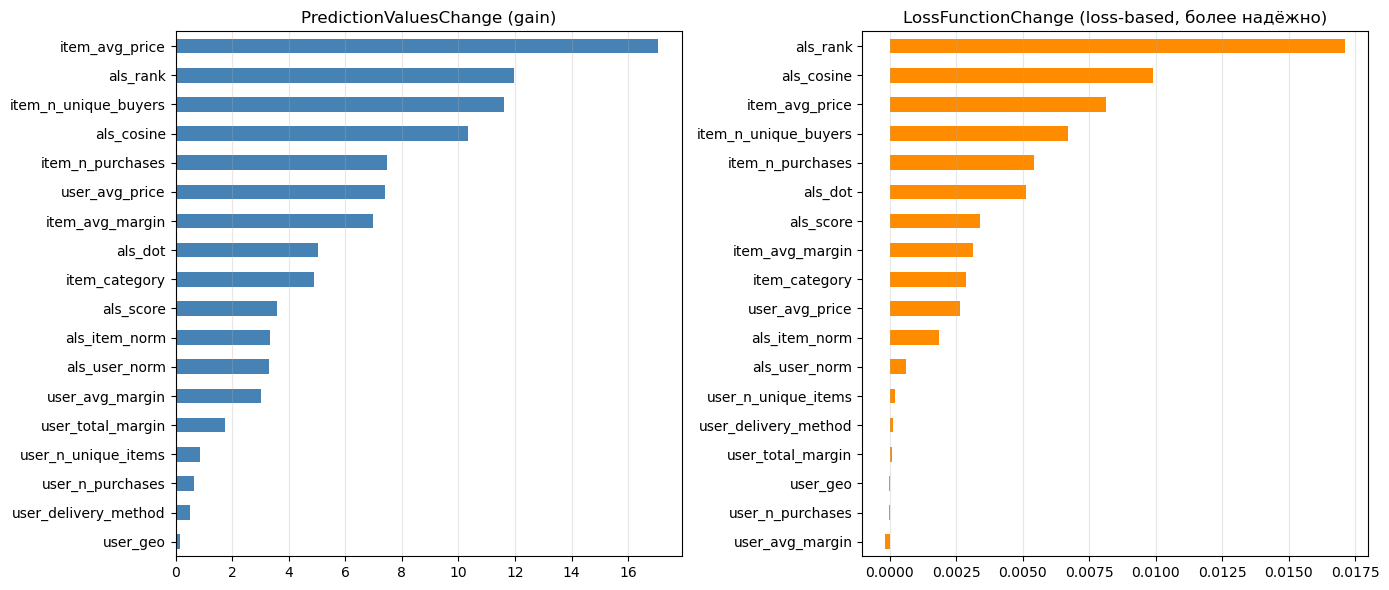

=== Топ-3 (gain) ===
item_avg_price          17.045103
als_rank                11.976474
item_n_unique_buyers    11.617996

=== Топ-3 (loss-based) ===
als_rank          0.017129
als_cosine        0.009885
item_avg_price    0.008138


In [16]:
imp_gain = pd.Series(
    cb_model.get_feature_importance(type='PredictionValuesChange'),
    index=FEATURE_COLS,
).sort_values(ascending=False)

imp_loss = pd.Series(
    cb_model.get_feature_importance(type='LossFunctionChange', data=val_pool),
    index=FEATURE_COLS,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_gain.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PredictionValuesChange (gain)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

imp_loss.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('LossFunctionChange (loss-based, более надёжно)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Топ-3 (gain) ===')
print(imp_gain.head(3).to_string())
print('\n=== Топ-3 (loss-based) ===')
print(imp_loss.head(3).to_string())

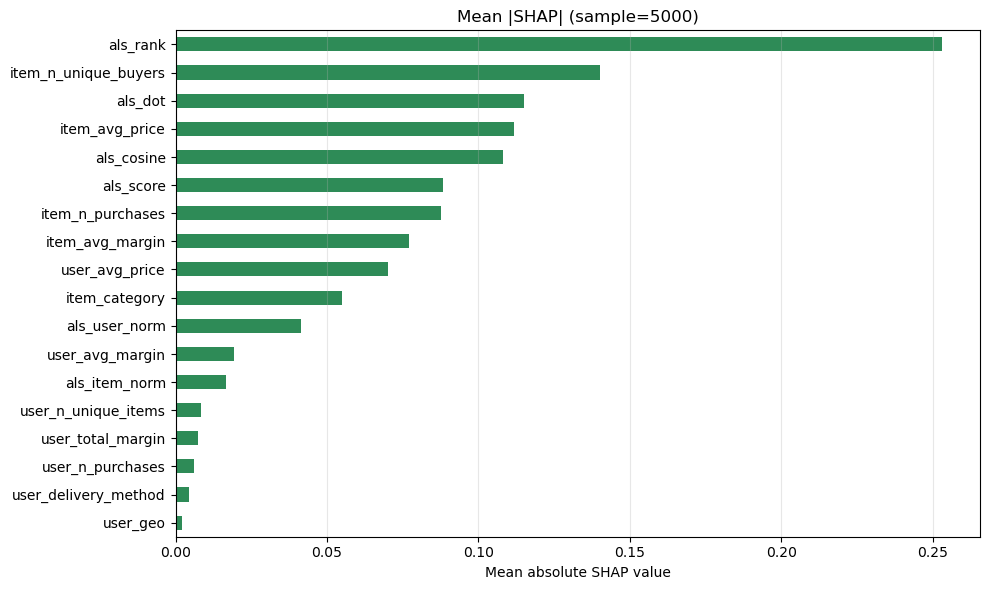

=== Топ-3 (mean |SHAP|) ===
als_rank                0.252947
item_n_unique_buyers    0.140003
als_dot                 0.114914


In [17]:
SHAP_SAMPLE = 5000
shap_sample_df = cb_val.head(SHAP_SAMPLE).copy()
shap_pool = make_pool(shap_sample_df, FEATURE_COLS, CAT_FEATURES)
shap_values = cb_model.get_feature_importance(type='ShapValues', data=shap_pool)

# CatBoost ShapValues format: (n_samples, n_features+1) — последняя колонка bias
shap_arr = np.asarray(shap_values)[:, :-1]
shap_df = pd.DataFrame(shap_arr, columns=FEATURE_COLS)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mean_abs_shap.plot(kind='barh', ax=ax, color='seagreen')
ax.invert_yaxis()
ax.set_title(f'Mean |SHAP| (sample={SHAP_SAMPLE})')
ax.set_xlabel('Mean absolute SHAP value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== Топ-3 (mean |SHAP|) ===')
print(mean_abs_shap.head(3).to_string())

if SHAP_AVAILABLE:
    # beeswarm — только числовые фичи (категориальные плохо рисуются)
    num_feats = [f for f in FEATURE_COLS if f not in CAT_FEATURES]
    shap.summary_plot(
        shap_df[num_feats].values,
        shap_sample_df[num_feats].values,
        feature_names=num_feats,
        show=False,
    )
    plt.tight_layout()
    plt.show()

In [18]:
FEATURE_GROUPS = {
    'collab':           ['als_score', 'als_rank', 'als_dot', 'als_cosine', 'als_user_norm', 'als_item_norm'],
    'user_numeric':     ['user_n_purchases', 'user_n_unique_items', 'user_avg_price', 'user_total_margin', 'user_avg_margin'],
    'user_categorical': ['user_geo', 'user_delivery_method'],
    'item_numeric':     ['item_n_purchases', 'item_n_unique_buyers', 'item_avg_price', 'item_avg_margin'],
    'item_categorical': ['item_category'],
}
print({g: len(cols) for g, cols in FEATURE_GROUPS.items()})

{'collab': 6, 'user_numeric': 5, 'user_categorical': 2, 'item_numeric': 4, 'item_categorical': 1}


In [19]:
group_ablation_results = {}

for group_name, group_cols in FEATURE_GROUPS.items():
    feats = [f for f in FEATURE_COLS if f not in group_cols]
    cats  = [f for f in CAT_FEATURES if f in feats]
    print(f'-- ablate {group_name}: {len(feats)} features remain')

    tp = make_pool(cb_train, feats, cats)
    vp = make_pool(cb_val, feats, cats)
    m  = train_catboost(tp, vp, verbose=0)
    res = evaluate_hybrid(dataset, m, feats, test_user_items)
    group_ablation_results[group_name] = res
    delta = res[10]['ndcg'] - baseline_results[10]['ndcg']
    print(f'    NDCG@10 = {res[10]["ndcg"]:.4f}  (Δ vs baseline = {delta:+.4f})')

-- ablate collab: 12 features remain
    NDCG@10 = 0.0753  (Δ vs baseline = -0.0273)
-- ablate user_numeric: 13 features remain
    NDCG@10 = 0.1032  (Δ vs baseline = +0.0006)
-- ablate user_categorical: 16 features remain
    NDCG@10 = 0.0988  (Δ vs baseline = -0.0038)
-- ablate item_numeric: 14 features remain
    NDCG@10 = 0.0953  (Δ vs baseline = -0.0073)
-- ablate item_categorical: 17 features remain
    NDCG@10 = 0.1031  (Δ vs baseline = +0.0005)


                  ndcg@10  map@10  Δ_ndcg@10
collab             0.0753  0.0451    -0.0273
item_numeric       0.0953  0.0606    -0.0073
user_categorical   0.0988  0.0633    -0.0038
item_categorical   0.1031  0.0668     0.0005
user_numeric       0.1032  0.0667     0.0006


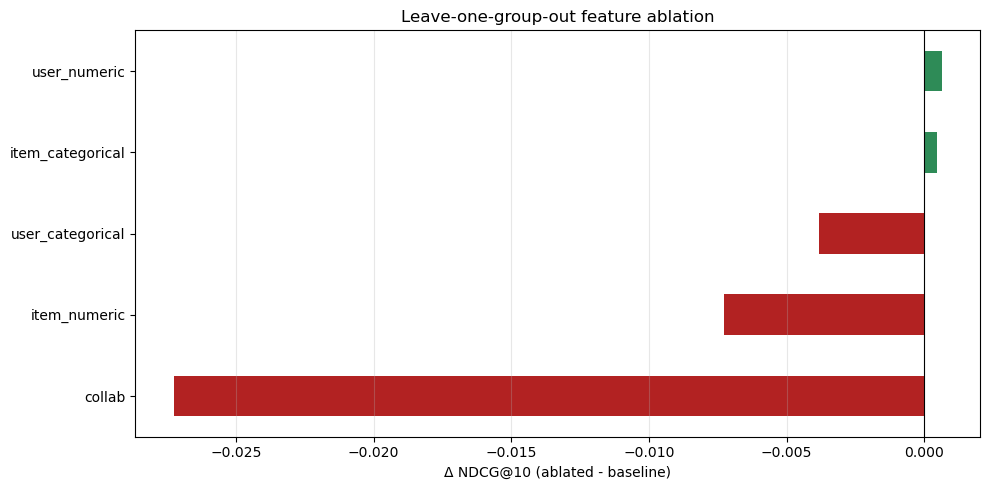

In [20]:
ablation_df = pd.DataFrame({
    g: {f'{m}@{k}': r[k][m] for k in K_VALUES for m in ['precision','recall','map','ndcg']}
    for g, r in group_ablation_results.items()
}).T
ablation_df['Δ_ndcg@10'] = ablation_df['ndcg@10'] - baseline_results[10]['ndcg']
ablation_df = ablation_df.sort_values('Δ_ndcg@10')
print(ablation_df[['ndcg@10', 'map@10', 'Δ_ndcg@10']].round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['firebrick' if d < 0 else 'seagreen' for d in ablation_df['Δ_ndcg@10']]
ablation_df['Δ_ndcg@10'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ NDCG@10 (ablated - baseline)')
ax.set_title('Leave-one-group-out feature ablation')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
TOP_N_SINGLE = 5
top_features = imp_loss.head(TOP_N_SINGLE).index.tolist()
print(f'Top-{TOP_N_SINGLE} features by LossFunctionChange: {top_features}')

single_ablation_results = {}
for feat in top_features:
    feats = [f for f in FEATURE_COLS if f != feat]
    cats  = [f for f in CAT_FEATURES if f in feats]
    print(f'-- ablate single feature: {feat}')

    tp = make_pool(cb_train, feats, cats)
    vp = make_pool(cb_val, feats, cats)
    m  = train_catboost(tp, vp, verbose=0)
    res = evaluate_hybrid(dataset, m, feats, test_user_items)
    single_ablation_results[feat] = res
    delta = res[10]['ndcg'] - baseline_results[10]['ndcg']
    print(f'    NDCG@10 = {res[10]["ndcg"]:.4f}  (Δ = {delta:+.4f})')

Top-5 features by LossFunctionChange: ['als_rank', 'als_cosine', 'item_avg_price', 'item_n_unique_buyers', 'item_n_purchases']
-- ablate single feature: als_rank
    NDCG@10 = 0.1033  (Δ = +0.0007)
-- ablate single feature: als_cosine
    NDCG@10 = 0.1039  (Δ = +0.0013)
-- ablate single feature: item_avg_price
    NDCG@10 = 0.1027  (Δ = +0.0001)
-- ablate single feature: item_n_unique_buyers
    NDCG@10 = 0.1038  (Δ = +0.0012)
-- ablate single feature: item_n_purchases
    NDCG@10 = 0.1005  (Δ = -0.0021)


In [22]:
all_variants = {'als_baseline': als_results, 'catboost_full': baseline_results}
for g, r in group_ablation_results.items():
    all_variants[f'ablate_group_{g}'] = r
for f, r in single_ablation_results.items():
    all_variants[f'ablate_feat_{f}'] = r

summary_rows = []
for name, res in all_variants.items():
    row = {'variant': name}
    for k in K_VALUES:
        for m in ['precision','recall','map','ndcg']:
            row[f'{m}@{k}'] = round(res[k][m], 4)
    row['Δ_ndcg@10'] = round(res[10]['ndcg'] - baseline_results[10]['ndcg'], 4)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('variant')
print(summary_df.to_string())

                                  precision@5  recall@5   map@5  ndcg@5  precision@10  recall@10  map@10  ndcg@10  precision@20  recall@20  map@20  ndcg@20  Δ_ndcg@10
variant                                                                                                                                                               
als_baseline                           0.0513    0.0613  0.0492  0.0715        0.0395     0.0833  0.0458   0.0746        0.0299     0.1107  0.0462   0.0822    -0.0280
catboost_full                          0.0669    0.0831  0.0708  0.0999        0.0502     0.1084  0.0663   0.1026        0.0348     0.1339  0.0656   0.1082     0.0000
ablate_group_collab                    0.0467    0.0637  0.0460  0.0689        0.0383     0.0888  0.0451   0.0753        0.0287     0.1159  0.0458   0.0831    -0.0273
ablate_group_user_numeric              0.0687    0.0841  0.0720  0.1014        0.0507     0.1090  0.0667   0.1032        0.0352     0.1346  0.0660   0.1088     0.000

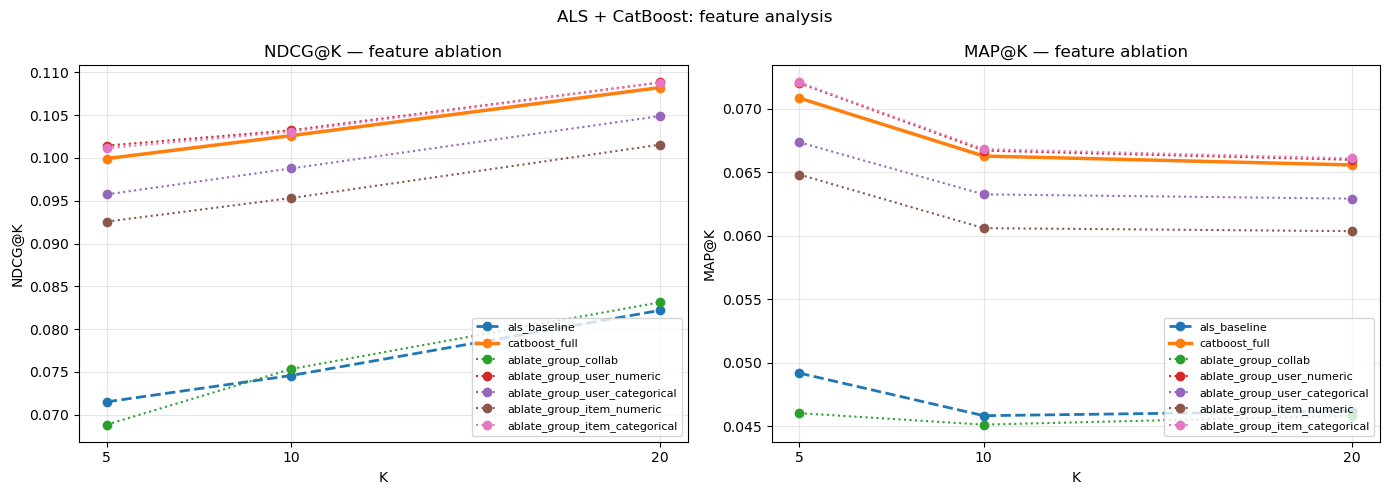

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_variants = ['als_baseline', 'catboost_full'] + [f'ablate_group_{g}' for g in FEATURE_GROUPS]
palette = sns.color_palette('tab10', len(plot_variants))

for ax, metric in zip(axes, ['ndcg', 'map']):
    for name, color in zip(plot_variants, palette):
        ys = [all_variants[name][k][metric] for k in K_VALUES]
        if name == 'catboost_full':
            ls, lw = '-', 2.5
        elif name == 'als_baseline':
            ls, lw = '--', 2.0
        else:
            ls, lw = ':', 1.5
        ax.plot(K_VALUES, ys, marker='o', label=name, color=color, linestyle=ls, linewidth=lw)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K — feature ablation')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(K_VALUES)

plt.suptitle('ALS + CatBoost: feature analysis', fontsize=12)
plt.tight_layout()
plt.show()

## Latency benchmark: ALS + CatBoost (two-stage)

Замеры per-user latency для каждого этапа:
- **stage1**: ALS top-100 кандидатов (CPU + GPU где возможно)
- **stage2**: CatBoost rerank на заготовленных 100 кандидатах (CPU only — модель содержит категориальные фичи)
- **e2e**: полный пайплайн (ALS → построение фичей → CatBoost predict → top-K)

In [24]:
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    _utils = _cand / 'source' / 'utils'
    if _utils.exists():
        sys.path.insert(0, str(_utils))
        break
import importlib, timing as _t
importlib.reload(_t)
from timing import benchmark_user_latency, save_benchmark, detect_hardware

rng = np.random.RandomState(SEED)
sample_size = min(2000, len(eval_users))
bench_users = rng.choice(eval_users, size=sample_size, replace=False).tolist()
print(f'Benchmarking on {len(bench_users)} users (warmup=50, k=10, N_CANDIDATES={N_CANDIDATES})')

DATASET_META = {
    'n_users': int(n_users), 'n_items': int(n_items),
    'n_train_pairs': int(train_matrix.nnz),
    'min_interactions': MIN_INTERACTIONS,
    'split_quantile': SPLIT_QUANTILE,
    'als_time_decay': bool(ALS_USE_TIME_DECAY),
    'als_lambda': float(ALS_BEST_LAMBDA),
    'n_candidates': int(N_CANDIDATES),
}
ALS_EXTRA_BASE = {
    'library': 'implicit',
    'factors': ALS_BEST_FACTORS,
    'regularization': ALS_BEST_REGULARIZATION,
    'iterations': ALS_BEST_ITERATIONS,
}

Benchmarking on 2000 users (warmup=50, k=10, N_CANDIDATES=100)


In [ ]:
def als_cpu_stage1(uid):
    item_ids, scores = als_model.recommend(
        uid, train_matrix[uid], N=N_CANDIDATES, filter_already_liked_items=True
    )
    return item_ids, scores

stats_s1_cpu = benchmark_user_latency(
    als_cpu_stage1, bench_users, warmup=50, k=10, sync_cuda=False, label='ALS+CB stage1 CPU'
)
print(f"ALS-CPU stage1: mean={stats_s1_cpu['mean_ms']:.3f}ms  p50={stats_s1_cpu['p50_ms']:.3f}  p95={stats_s1_cpu['p95_ms']:.3f}")
save_benchmark(
    stats_s1_cpu, model_name='ALS+CatBoost', stage='stage1',
    hardware=detect_hardware(prefer='cpu'),
    dataset_meta=DATASET_META,
    extra={**ALS_EXTRA_BASE, 'use_gpu': False, 'sync_cuda': False, 'stage_desc': 'ALS top-N candidates'},
    notebook='experiments/als_catboost_experiments.ipynb', n_items=n_items,
)

ALS-CPU stage1: mean=0.245ms  p50=0.125  p95=0.693


'ALS+CatBoost_stage1_20260509T153230'

In [26]:
# --- stage1 ALS-GPU (если доступно) ---
import implicit
try:
    has_cuda = bool(implicit.gpu.HAS_CUDA)
except Exception:
    has_cuda = False
print(f'implicit.gpu.HAS_CUDA = {has_cuda}')

als_gpu_model = None
if has_cuda:
    from implicit.gpu.als import AlternatingLeastSquares as ALS_GPU
    factors_gpu = ((ALS_BEST_FACTORS + 31) // 32) * 32
    als_gpu_model = ALS_GPU(
        factors=factors_gpu,
        regularization=ALS_BEST_REGULARIZATION,
        iterations=ALS_BEST_ITERATIONS,
        random_state=SEED,
    )
    als_gpu_model.fit(train_matrix, show_progress=False)

    def als_gpu_stage1(uid):
        item_ids, scores = als_gpu_model.recommend(
            uid, train_matrix[uid], N=N_CANDIDATES, filter_already_liked_items=True
        )
        return item_ids, scores

    stats_s1_gpu = benchmark_user_latency(
        als_gpu_stage1, bench_users, warmup=50, k=10, sync_cuda=False, label='ALS+CB stage1 GPU'
    )
    print(f"ALS-GPU stage1: mean={stats_s1_gpu['mean_ms']:.3f}ms  p50={stats_s1_gpu['p50_ms']:.3f}  p95={stats_s1_gpu['p95_ms']:.3f}")
    save_benchmark(
        stats_s1_gpu, model_name='ALS+CatBoost', stage='stage1',
        hardware=detect_hardware(prefer='gpu'),
        dataset_meta=DATASET_META,
        extra={**ALS_EXTRA_BASE, 'factors': factors_gpu,
               'use_gpu': True, 'implicit_HAS_CUDA': True, 'sync_cuda': False,
               'stage_desc': 'ALS top-N candidates'},
        notebook='experiments/als_catboost_experiments.ipynb', n_items=n_items,
    )
else:
    print('Skipping ALS-GPU stage1: implicit GPU not available')

implicit.gpu.HAS_CUDA = False
Skipping ALS-GPU stage1: implicit GPU not available


In [27]:
# --- stage2 CatBoost rerank (только rerank на 100 заготовленных кандидатах; CPU only из-за categorical features) ---
# Заготовим уникальные DataFrame'ы фичей per-user (без кеширования)
feat_by_user = {
    int(u): grp[FEATURE_COLS].copy()
    for u, grp in dataset.groupby('user_id')
}
bench_users_present = [u for u in bench_users if u in feat_by_user]
print(f'feat_by_user готов для {len(feat_by_user)} users; bench пересечение: {len(bench_users_present)}')

def cb_stage2(uid):
    feats = feat_by_user[uid]
    scores = cb_model.predict(feats)
    order = np.argsort(-scores)
    return order[:10]

stats_s2 = benchmark_user_latency(
    cb_stage2, bench_users_present, warmup=50, k=10, sync_cuda=False, label='ALS+CB stage2 CPU'
)
print(f"CatBoost stage2: mean={stats_s2['mean_ms']:.3f}ms  p50={stats_s2['p50_ms']:.3f}  p95={stats_s2['p95_ms']:.3f}")
save_benchmark(
    stats_s2, model_name='ALS+CatBoost', stage='stage2',
    hardware=detect_hardware(prefer='cpu'),
    dataset_meta=DATASET_META,
    extra={'library': 'catboost', 'cat_features': CAT_FEATURES,
           'n_features': len(FEATURE_COLS),
           'best_iteration': int(cb_model.get_best_iteration()),
           'task_type': 'CPU',
           'stage_desc': 'CatBoost rerank on prebuilt 100-cand DataFrame'},
    notebook='experiments/als_catboost_experiments.ipynb', n_items=n_items,
)

feat_by_user готов для 7128 users; bench пересечение: 2000
CatBoost stage2: mean=0.506ms  p50=0.355  p95=0.404


'ALS+CatBoost_stage2_20260509T153233'

In [ ]:
_uf_by_user = user_features.set_index('user_id').to_dict('index')
_if_by_item = item_features.set_index('item_id').to_dict('index')
user_factors_arr = np.asarray(als_model.user_factors)
item_factors_arr = np.asarray(als_model.item_factors)

def _build_features_for(uid, item_ids, scores, user_factors, item_factors):
    n = len(item_ids)
    item_ids_arr = np.asarray(item_ids, dtype=np.int64)
    scores_arr = np.asarray(scores, dtype=np.float64)
    u_vec = user_factors[uid]
    i_vecs = item_factors[item_ids_arr]
    als_dot = (i_vecs * u_vec).sum(axis=1)
    u_norm = float(np.linalg.norm(u_vec))
    i_norms = np.linalg.norm(i_vecs, axis=1)
    als_cos = als_dot / (u_norm * i_norms + 1e-10)
    als_rank = np.arange(1, n + 1)

    uf = _uf_by_user.get(uid, {})
    user_geo = uf.get('user_geo', 'Неизвестно')
    user_dm = uf.get('user_delivery_method', 'Неизвестно')
    user_n_purchases = uf.get('user_n_purchases', 0)
    user_n_unique_items = uf.get('user_n_unique_items', 0)
    user_avg_price = uf.get('user_avg_price', 0.0)
    user_total_margin = uf.get('user_total_margin', 0.0)
    user_avg_margin = uf.get('user_avg_margin', 0.0)

    item_n_purchases = np.empty(n)
    item_n_unique_buyers = np.empty(n)
    item_avg_price = np.empty(n)
    item_avg_margin = np.empty(n)
    item_category = []
    for j, it in enumerate(item_ids_arr):
        ifr = _if_by_item.get(int(it), {})
        item_n_purchases[j] = ifr.get('item_n_purchases', 0)
        item_n_unique_buyers[j] = ifr.get('item_n_unique_buyers', 0)
        item_avg_price[j] = ifr.get('item_avg_price', 0.0)
        item_avg_margin[j] = ifr.get('item_avg_margin', 0.0)
        item_category.append(ifr.get('item_category', 'Неизвестно'))

    return pd.DataFrame({
        'als_score': scores_arr, 'als_rank': als_rank,
        'als_dot': als_dot, 'als_cosine': als_cos,
        'als_user_norm': np.full(n, u_norm), 'als_item_norm': i_norms,
        'user_n_purchases': user_n_purchases, 'user_n_unique_items': user_n_unique_items,
        'user_avg_price': user_avg_price, 'user_total_margin': user_total_margin,
        'user_avg_margin': user_avg_margin,
        'user_geo': user_geo, 'user_delivery_method': user_dm,
        'item_n_purchases': item_n_purchases, 'item_n_unique_buyers': item_n_unique_buyers,
        'item_avg_price': item_avg_price, 'item_avg_margin': item_avg_margin,
        'item_category': item_category,
    })


def e2e_cpu(uid):
    item_ids, scores = als_model.recommend(
        uid, train_matrix[uid], N=N_CANDIDATES, filter_already_liked_items=True
    )
    feats = _build_features_for(uid, item_ids, scores, user_factors_arr, item_factors_arr)
    cb_scores = cb_model.predict(feats[FEATURE_COLS])
    order = np.argsort(-cb_scores)
    return [int(item_ids[i]) for i in order[:10]]

stats_e2e_cpu = benchmark_user_latency(
    e2e_cpu, bench_users, warmup=50, k=10, sync_cuda=False, label='ALS+CB e2e CPU'
)
print(f"ALS+CB e2e CPU: mean={stats_e2e_cpu['mean_ms']:.3f}ms  p50={stats_e2e_cpu['p50_ms']:.3f}  p95={stats_e2e_cpu['p95_ms']:.3f}")
save_benchmark(
    stats_e2e_cpu, model_name='ALS+CatBoost', stage='e2e',
    hardware=detect_hardware(prefer='cpu'),
    dataset_meta=DATASET_META,
    extra={**ALS_EXTRA_BASE, 'use_gpu': False, 'cb_task_type': 'CPU',
           'stage_desc': 'ALS recommend N=100 + on-the-fly feature build + CatBoost predict + top-10'},
    notebook='experiments/als_catboost_experiments.ipynb', n_items=n_items,
)

ALS+CB e2e CPU: mean=1.719ms  p50=1.102  p95=4.024


'ALS+CatBoost_e2e_20260509T153237'